# PM trade evaluation — memory & answer-space A/B

The PM produces two things that get scored: a signed conviction per driver (graded in
*driver space* against each driver's own level, `pm_bench`) and a `StrategyTrade` that
crosses the PM→fund seam (graded in *yield space*, `trade_pnl`).

The first duration run exposed two defects — both design, not judgment (see
`docs/pm-layer.md` §1). This notebook is the A/B that tested the fixes:

- **OFF** — `duration_on.jsonl`. Memory off, pre-`answer_space`. The mandate spoke in rate
  space while the `conviction` field spoke in driver space, so the two negative-polarity
  drivers were graded against the wrong sign.
- **ON** — `duration_mem_on.jsonl`. Memory on, `answer_space: driver`. The PM sees its own
  previous position, and both halves of the prompt agree on what a conviction means.
- **MECH** — `duration_mech.jsonl`. The deterministic control: a polarity-weighted rule
  over the same board, no model, no spend. The bar the LLM has to clear.

**Sign convention.** Yield-space P&L is `Σ w · Δy` — a positive weight bets the yield
*rises*. NOT a bond return (long duration earns when yields fall), not duration-weighted.
Everything is in percentage points of yield.

In [1]:
import os, sys, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))
from src.layered.evaluation import (load_pm_run, load_trades, yield_pnl, score_trades,
                                    trade_validity)
from src.layered.evaluation.pm_bench import analyst_snap, benchmark
from src.layered.pm.build import build_pm, build_board
from src.data.fred_local import load_bundle

POD  = "duration"
ARMS = {"off":  "../reports/pm/duration_on.jsonl",
        "on":   "../reports/pm/duration_mem_on.jsonl",
        "mech": "../reports/pm/duration_mech.jsonl"}

pm    = build_pm(POD, None)
cfg   = pm.trade_config
INSTS = list(cfg["universe"])
pol   = pm.polarity
macro = load_bundle(INSTS)
board = build_board(pm, "../reports/ab", "_on")

A = {}
for label, path in ARMS.items():
    run = load_pm_run(path)
    tr  = load_trades(path, cfg)
    pnl = yield_pnl(tr, macro, INSTS, freq=pm.clock_freq)
    A[label] = {"run": run, "tr": tr, "pnl": pnl, "path": path}
    print(f"[{label:4s}] meetings={len(run.degraded):3d} degraded={int(run.degraded.sum())} "
          f"answer_space={run.meta.get('answer_space','(unrecorded)')} "
          f"memory={run.meta.get('memory','(unrecorded)')}  {path}")

/Users/eliasroubache/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/eliasroubache/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


[off ] meetings=120 degraded=0 answer_space=(unrecorded) memory=(unrecorded)  ../reports/pm/duration_on.jsonl
[on  ] meetings=120 degraded=1 answer_space=driver memory=True  ../reports/pm/duration_mem_on.jsonl
[mech] meetings=120 degraded=0 answer_space=driver memory=False  ../reports/pm/duration_mech.jsonl


## 1 · Driver block — does the PM track its analyst now?

The headline defect was the driver table scoring 0/5. Split by polarity, the two
negative-polarity drivers (balance_sheet, labor_tightness) decoupled from their analysts
while the three positive ones tracked. If the `answer_space` fix works, the two −1 drivers
should snap back and the +1 drivers should be roughly unchanged.

In [2]:
rows = []
for label in ("off", "on"):
    run = A[label]["run"]
    dates = pd.DatetimeIndex(run.frame.index)
    snap  = analyst_snap(board, dates, pm.listens_to)
    for d in pm.listens_to:
        j = pd.concat([snap[d].rename("a"), run.frame[d].rename("p")], axis=1).dropna()
        nz = j[(j.a != 0) & (j.p != 0)]
        rows.append({"arm": label, "driver": d, "polarity": pol[d],
                     "corr": j.a.rank().corr(j.p.rank()),
                     "sign_agree": (np.sign(nz.a) == np.sign(nz.p)).mean() if len(nz) else np.nan})
piv = pd.DataFrame(rows).pivot(index="driver", columns="arm", values=["corr", "sign_agree"])
piv["polarity"] = [pol[d] for d in piv.index]
piv.round(3)

corr        sign_agree        polarity
arm                     off     on        off     on         
driver                                                       
balance_sheet        -0.168  0.996      0.444  1.000     -1.0
financial_conditions  0.818  0.970      0.921  1.000      1.0
inflation             0.960  0.983      1.000  1.000      1.0
labor_tightness      -0.050  0.865      0.510  0.981     -1.0
term_premium          0.960  0.985      0.989  1.000      1.0

## 2 · Driver IC — PM vs its analyst, graded in the pod's declared space

`benchmark` is told each run's `answer_space` so the grade matches what the model was
asked. `ic_mech` is the polarity-weighted-panel control from `pm_bench`. Read the sign
consistency and the win count, not any single row — a Δic of ±0.05 is noise at this breadth.

In [3]:
for label in ("off", "on"):
    run = A[label]["run"]
    space = run.meta.get("answer_space", "driver")
    tbl = benchmark(run.frame, board, pd.DatetimeIndex(run.frame.index), pol,
                    answer_space=space)
    A[label]["bench"] = tbl
    print(f"--- arm={label}  (graded as answer_space={space!r})")
    print(tbl[["n", "ic_analyst", "ic_pm", "d_ic", "ic_mech", "t_pm"]].round(3).to_string())
    print(f"    PM beat its analyst on {(tbl.d_ic > 0).sum()}/{len(tbl)}; "
          f"mean d_ic {tbl.d_ic.mean():+.3f}\n")

--- arm=off  (graded as answer_space='driver')
                        n  ic_analyst  ic_pm   d_ic  ic_mech   t_pm
driver                                                             
inflation             119       0.426  0.418 -0.007    0.343  4.980
labor_tightness       108       0.156  0.050 -0.106    0.158  0.519
term_premium          118       0.023  0.022 -0.001    0.003  0.235
financial_conditions  118       0.442  0.346 -0.096    0.457  3.971
balance_sheet         116       0.714 -0.167 -0.881    0.666 -1.813
    PM beat its analyst on 0/5; mean d_ic -0.218

--- arm=on  (graded as answer_space='driver')
                        n  ic_analyst  ic_pm   d_ic  ic_mech    t_pm
driver                                                              
inflation             118       0.418  0.425  0.007    0.338   5.062
labor_tightness       118       0.157  0.173  0.016    0.159   1.888
term_premium          118       0.023  0.031  0.008    0.004   0.331
financial_conditions  118       0.43

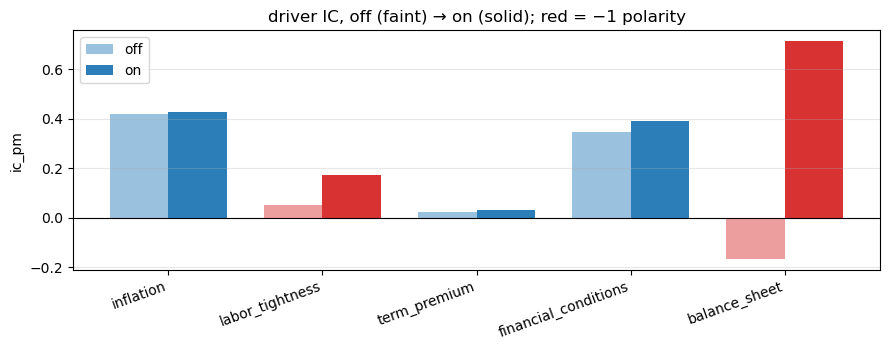

In [4]:
# The recovery, at a glance: ic_pm off vs on, coloured by polarity.
off_ic = A["off"]["bench"]["ic_pm"]; on_ic = A["on"]["bench"]["ic_pm"]
drivers = list(on_ic.index)
x = np.arange(len(drivers)); w = 0.38
colors = ["tab:red" if pol[d] < 0 else "tab:blue" for d in drivers]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(x - w/2, off_ic.reindex(drivers), w, label="off", color=colors, alpha=.45)
ax.bar(x + w/2, on_ic.reindex(drivers), w, label="on", color=colors, alpha=.95)
ax.axhline(0, color="k", lw=.8)
ax.set_xticks(x); ax.set_xticklabels(drivers, rotation=20, ha="right")
ax.set_ylabel("ic_pm"); ax.set_title("driver IC, off (faint) → on (solid); red = −1 polarity")
ax.legend(); ax.grid(axis="y", alpha=.3); plt.tight_layout()

## 3 · Behaviour — turnover, holds, and does it chase?

The stateless PM re-struck the whole book monthly. Memory should show up as lower
|Δnet|, more unchanged holds, and a weaker chase correlation. `sign_violations` and
`legs_dropped` should stay at zero — the fixes must not have loosened the trade grounding.

In [5]:
g10 = macro["DGS10"].dropna().resample("ME").last()
rows = []
for label in ("off", "on", "mech"):
    tr, pnl = A[label]["tr"], A[label]["pnl"]
    h = tr[tr.has_trade]; net = h["net"]
    flips = (np.sign(net) != np.sign(net.shift())).iloc[1:]
    holds = (h[[f"w_{i}" for i in INSTS]].diff().abs().sum(axis=1) == 0).iloc[1:]
    prev = (g10 - g10.shift()).reindex(net.index)
    v = trade_validity(tr)
    rows.append({"arm": label, "emission": tr.has_trade.mean(),
                 "flat_rate": v.get("flat_rate", np.nan), "mean_gross": h.gross.mean(),
                 "mean_|dnet|": net.diff().abs().mean(), "sign_flips": flips.mean(),
                 "unchanged_holds": holds.mean(), "chase_corr": prev.corr(net),
                 "sign_violations": v["sign_violation_rate"]})
pd.DataFrame(rows).set_index("arm").round(3)

,emission,flat_rate,mean_gross,mean_|dnet|,sign_flips,unchanged_holds,chase_corr,sign_violations
arm,,,,,,,,
off,0.9,0.000,0.904,0.896,0.458,0.065,0.522,0.0
on,1.0,0.000,0.238,0.122,0.110,0.212,0.451,0.0
mech,1.0,0.025,0.975,0.639,0.336,0.664,0.342,0.0


## 4 · Trade — yield-space P&L

The bar is the mechanical control, not zero: does a model reading seven reports beat a
polarity-weighted rule over the same reports? Read t and the regime table, not the Sharpe —
at ~12 bets/yr its standard error is wide, and with memory on the observations are no longer
independent (a few persistent positions carry the P&L), so t overstates the evidence.

In [6]:
rows = []
for label in ("off", "on", "mech"):
    tr, pnl = A[label]["tr"], A[label]["pnl"]
    sc = score_trades(pnl, tr.reindex(pnl.index)["conviction"])
    rows.append({"arm": label, **{k: sc[k] for k in
                 ("n", "mean", "t_stat", "hit_rate", "sharpe_ann", "ic_conviction")}})
pd.DataFrame(rows).set_index("arm").round(4)

,n,mean,t_stat,hit_rate,sharpe_ann,ic_conviction
arm,,,,,,
off,108,0.0017,0.0774,0.4630,0.0256,0.1865
on,119,0.0101,1.7300,0.5462,0.5444,0.0482
mech,120,0.0056,0.2606,0.4417,0.0817,0.0463


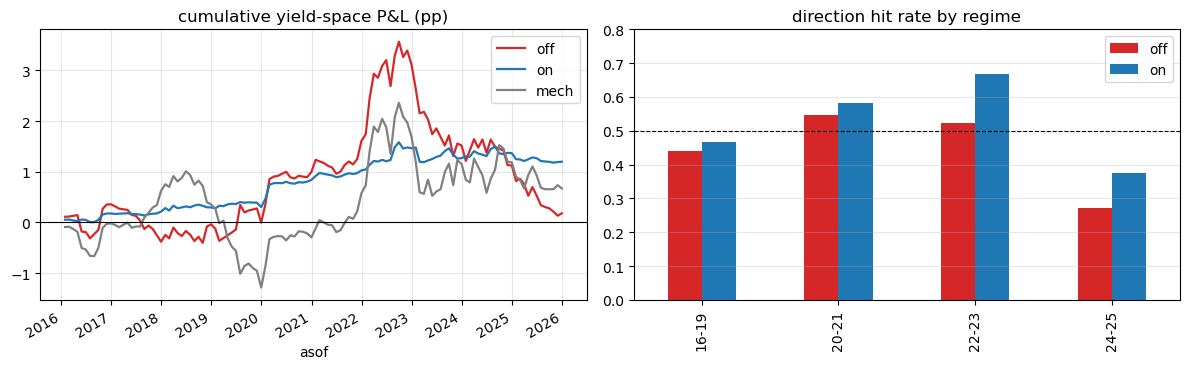

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for label, c in [("off", "tab:red"), ("on", "tab:blue"), ("mech", "0.5")]:
    A[label]["pnl"].cumsum().plot(ax=ax[0], lw=1.6, label=label, color=c)
ax[0].axhline(0, color="k", lw=.8); ax[0].legend()
ax[0].set_title("cumulative yield-space P&L (pp)"); ax[0].grid(alpha=.3)

hit = {}
for label in ("off", "on"):
    tr, pnl = A[label]["tr"], A[label]["pnl"]
    fwd = (g10.shift(-1) - g10).reindex(pnl.index)
    h = tr.reindex(pnl.index)
    d = (np.sign(h["net"]) == np.sign(fwd))
    hit[label] = {lab: d[(pnl.index.year >= lo) & (pnl.index.year <= hi)].mean()
                  for lo, hi, lab in [(2016, 2019, "16-19"), (2020, 2021, "20-21"),
                                      (2022, 2023, "22-23"), (2024, 2025, "24-25")]}
pd.DataFrame(hit).plot.bar(ax=ax[1], color=["tab:red", "tab:blue"])
ax[1].axhline(0.5, color="k", lw=.8, ls="--")
ax[1].set_title("direction hit rate by regime"); ax[1].set_ylim(0, 0.8)
ax[1].grid(axis="y", alpha=.3); plt.tight_layout()

In [8]:
# P&L by year, both arms.
by = pd.DataFrame({label: A[label]["pnl"].groupby(A[label]["pnl"].index.year).sum()
                   for label in ("off", "on", "mech")})
by.round(3)

,off,on,mech
asof,,,
2016,0.357,0.176,-0.020
2017,-0.738,0.037,0.645
2018,0.343,0.082,-0.270
2019,0.034,0.007,-1.640
2020,1.000,0.537,0.990
2021,0.614,0.188,0.875
2022,1.505,0.437,1.110
2023,-1.597,-0.194,-0.535
2024,-0.395,0.098,0.030


## 5 · Does the trade still follow the reconciled view?

The layer-boundary check, not a strategy check: the trade should be long yields exactly
when the pod's own oriented panel says rates rise. This held before the fixes (78.7%); it
must not have broken.

In [9]:
rows = []
for label in ("off", "on"):
    run, tr, pnl = A[label]["run"], A[label]["tr"], A[label]["pnl"]
    h = tr.reindex(pnl.index)
    oriented = run.frame.reindex(pnl.index).mul(pd.Series(pol)).mean(axis=1, skipna=True)
    coh = pd.DataFrame({"panel": oriented, "net": h["net"]}).dropna()
    agree = (np.sign(coh["panel"]) == np.sign(coh["net"]))
    rows.append({"arm": label, "n": len(coh), "sign_agree": agree.mean(),
                 "rank_corr": coh["panel"].rank().corr(coh["net"].rank())})
pd.DataFrame(rows).set_index("arm").round(3)

,n,sign_agree,rank_corr
arm,,,
off,108,0.787,0.693
on,119,0.748,0.591


## 6 · Verdict

**The two design fixes both land, and the driver-block recovery is the unambiguous result.**
Splitting by polarity confirmed the 0/5 was a contract artifact: with `answer_space: driver`
binding both halves of the prompt, balance_sheet's IC recovers from −0.167 to +0.713
(analyst +0.710) and labor_tightness from ~0 to +0.87 — the two negative-polarity drivers
that had decoupled. The headline goes 0/5 → 4/5, mean Δic −0.218 → −0.001.

**Memory collapsed the turnover.** Sign flips 45.8% → 11.0%, mean |Δnet| 0.896 → 0.122,
unchanged holds 6.5% → 21.2%. The PM now holds and nudges a position instead of re-striking
it every month — the over-trading was a design artifact (no incumbent position in the
prompt), not a judgment failure.

**The trade improved on every axis and cleared the mechanical control for the first time**
(t +0.26 mech vs +1.73 on), direction up in every regime including the 2024-25 cutting
cycle. But this is a feature-free pipeline: the honest reading is "not negative, leaning
positive", and with turnover this low the P&L is carried by a handful of persistent
positions, so t overstates the evidence.

### Caveats

- **The arms are entangled.** The ON run flips memory *and* `answer_space` together. Driver
  IC recovery is attributable to `answer_space` (re-orientation moves it); turnover collapse
  to memory (nothing else changes persistence). A clean four-cell factorial was not run.
- **`flat_rate` was 0%** — the PM always held some position; the flat affordance exists and
  is tested, it just was not chosen here.
- **Not a P&L, one pod is not a book.** Yield-space `Σ w·Δy`, no duration weighting / carry /
  costs; nothing allocates across pods or re-clips for vol. See `docs/pm-layer.md` §4.
- **Shared board.** Two legs of `reports/ab` were re-run after a billing failure; per-leg
  hashes are in each `.meta.json`.